<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/notebooks/janssen_snrna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Droplet-based single-nucleus RNA-seq with a genotype ground truth

The single-nucleus dataset analyzed elsewhere in the CellSweep manuscript (10x human kidney nuclei)
and the Parse 8-cubed experiments are both comparatively lowly contaminated. Droplet-based
single-nucleus RNA-seq is the regime where background RNA is most severe, because nuclei are
isolated by lysing cells and the resulting free RNA is carried into every droplet.

[Janssen et al. (2023), *Genome Biology* 24:140](https://doi.org/10.1186/s13059-023-02978-x)
generated exactly this kind of benchmark. Kidneys from three mouse strains -- one
*Mus musculus castaneus* (CAST/EiJ) and two *M. m. domesticus* (C57BL/6J and 129S1/SvImJ) -- were
pooled before droplet capture. Because the strains differ at ~32,000 homozygous SNPs, reads
carrying a foreign allele in a given nucleus are unambiguously background. Fitting a binomial
model to the cross-genotype allele counts gives a **per-cell ground-truth background fraction**
(`contPerCell_binom`, referred to as `bRNA` below) for every CAST nucleus.

Two of their five replicates are droplet-based snRNA-seq (`nuc2`, `nuc3`); the other three
(`rep1`--`rep3`) are scRNA-seq from the same animals. We use `nuc2` and `nuc3`.

This notebook

1. downloads the data and the companion code archive from Zenodo,
2. runs CellSweep on the raw CellRanger matrices using the authors' cell calls and SingleR labels,
3. scores CellSweep with **the authors' own metrics, computed by their own definitions**
   (Kendall's $\tau$ and RMSLE against the genotype estimate; PT-marker expression fraction),
4. compares those scores against the published CellBender / DecontX / SoupX values, which are
   shipped inside the code archive (`Analysis/files/benchmark_metrics.RDS`), and
5. checks that CellSweep behaves sensibly in this high-background regime.

Data: [10.5281/zenodo.7328632](https://doi.org/10.5281/zenodo.7328632) &nbsp;&nbsp;
Code: [10.5281/zenodo.7941521](https://doi.org/10.5281/zenodo.7941521)

Reading the `.RDS` files requires an R installation (`Rscript` on `PATH`); no R packages beyond
base R are needed.

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import json
import shutil
import subprocess
import zipfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from matplotlib.lines import Line2D
from scipy.stats import kendalltau

from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

## Configuration

In [4]:
dataset_name = "janssen2023"
replicates = ["nuc2", "nuc3"]      # the two droplet-based snRNA-seq replicates
verbose = 1                         # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False                   # recompute outputs that already exist
threads = 16                        # numba threads for CellSweep

# Non-cellular barcodes are every barcode below `empty_umi_cutoff` that the authors did not call
# as a cell. CellSweep's usual convention is to place this cutoff at the knee, but in these
# datasets the knee sits at 1,285 (nuc2) and 2,722 (nuc3) UMIs, so a knee cutoff sweeps
# near-cell barcodes into the ambient profile (see the sensitivity section at the end).
empty_umi_cutoff = 100
empty_cutoff_sweep = [100, 500, 1000, "knee"]   # used by the sensitivity section

data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

ZENODO_DATA = "https://zenodo.org/records/7328632/files"
ZENODO_CODE = ("https://zenodo.org/records/7941521/files/"
               "Hellmann-Lab/scRNA-seq_Contamination-first.zip")

# The 10 proximal-tubule markers Janssen et al. use for the marker-specificity metrics.
PT_MARKERS = ["Slc34a1", "Miox", "Pck1", "Slc4a4", "Ttc36", "Lrp2", "Fbp1", "Cyp2e1", "Fut9", "Khk"]

## Download

`nuc2.zip` (812 MB) and `nuc3.zip` (313 MB) each contain the raw and filtered CellRanger matrices,
the processed Seurat object (cell calls, SingleR cell types, strain assignments and the
genotype-based background estimate), and the per-cell genotype estimate on its own.

In [5]:
for rep in replicates:
    zip_path = os.path.join(data_dir, f"{rep}.zip")
    if not os.path.exists(os.path.join(data_dir, rep)):
        if not os.path.exists(zip_path):
            print(f"downloading {rep}.zip ...")
            !wget -q -c "{ZENODO_DATA}/{rep}.zip?download=1" -O {zip_path}
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(data_dir)
    print(rep, sorted(os.listdir(os.path.join(data_dir, rep))))

nuc2 ['adata_raw_empty100.h5ad', 'adata_raw_empty1000.h5ad', 'adata_raw_empty500.h5ad', 'adata_raw_emptyknee.h5ad', 'filtered_feature_bc_matrix.h5', 'nuc2_output_cellsweep_empty100.h5ad', 'nuc2_output_cellsweep_empty1000.h5ad', 'nuc2_output_cellsweep_empty500.h5ad', 'nuc2_output_cellsweep_emptyknee.h5ad', 'perCell_noMito_CAST_binom.RDS', 'raw_feature_bc_matrix.h5', 'seurat.RDS', 'seurat_CAST.RDS', 'seurat_metadata.csv']
nuc3 ['adata_raw_empty100.h5ad', 'adata_raw_empty1000.h5ad', 'adata_raw_empty500.h5ad', 'adata_raw_emptyknee.h5ad', 'filtered_feature_bc_matrix.h5', 'nuc3_output_cellsweep_empty100.h5ad', 'nuc3_output_cellsweep_empty1000.h5ad', 'nuc3_output_cellsweep_empty500.h5ad', 'nuc3_output_cellsweep_emptyknee.h5ad', 'perCell_noMito_CAST_binom.RDS', 'raw_feature_bc_matrix.h5', 'seurat.RDS', 'seurat_CAST.RDS', 'seurat_metadata.csv']


In [6]:
# The code archive carries the published benchmark numbers for CellBender, DecontX and SoupX.
code_zip = os.path.join(data_dir, "janssen_code.zip")
code_dir = os.path.join(data_dir, "janssen_code")
if not os.path.exists(code_dir):
    if not os.path.exists(code_zip):
        !wget -q -c "{ZENODO_CODE}?download=1" -O {code_zip}
    with zipfile.ZipFile(code_zip) as zf:
        zf.extractall(code_dir)
code_root = os.path.join(code_dir, os.listdir(code_dir)[0])
print(code_root)

/home/jrich/Desktop/cellsweep/notebooks/data/janssen2023/janssen_code/Hellmann-Lab-scRNA-seq_Contamination-4645c7a


## Read the R objects

The cell calls, cell-type labels, strain assignments and the genotype ground truth live in Seurat
`.RDS` files. We pull the metadata out with base R -- S4 slots are stored as attributes, so
`attr(x, "meta.data")` works without installing Seurat -- and write it to CSV.

In [7]:
R_EXPORT = r"""
suppressWarnings({
  args <- commandArgs(TRUE)               # one directory per replicate, then the shared data dir
  for (d in args[-length(args)]) {
    seu <- readRDS(file.path(d, "seurat.RDS"))
    md <- as.data.frame(attr(seu, "meta.data"))
    md$cell <- rownames(md)
    write.csv(md, file.path(d, "seurat_metadata.csv"), row.names = FALSE)
    cat(d, ": ", nrow(md), " cells, ", ncol(md), " metadata columns\n", sep = "")
    rm(seu); gc()
  }
  bm <- as.data.frame(readRDS(file.path(args[length(args)], "benchmark_metrics.RDS")))
  write.csv(bm, file.path(args[length(args)], "benchmark_metrics.csv"), row.names = FALSE)
})
"""

bench_src = os.path.join(code_root, "Analysis", "files", "benchmark_metrics.RDS")
shutil.copy(bench_src, os.path.join(data_dir, "benchmark_metrics.RDS"))

script = os.path.join(data_dir, "export_rds.R")
with open(script, "w") as f:
    f.write(R_EXPORT)

targets = [os.path.join(data_dir, rep) for rep in replicates] + [data_dir]
expected_csvs = ([os.path.join(data_dir, r, "seurat_metadata.csv") for r in replicates]
                 + [os.path.join(data_dir, "benchmark_metrics.csv")])
if overwrite or not all(os.path.exists(p) for p in expected_csvs):
    done = subprocess.run(["Rscript", script] + targets, capture_output=True, text=True)
    print(done.stdout or done.stderr)

In [8]:
metadata = {rep: pd.read_csv(os.path.join(data_dir, rep, "seurat_metadata.csv")).set_index("cell")
            for rep in replicates}
for rep, md_df in metadata.items():
    gt = md_df["bRNA"].dropna()
    print(f"{rep}: {len(md_df):,} cells  |  strains: {dict(md_df['Strain'].value_counts())}")
    print(f"      genotype ground truth for {len(gt):,} CAST nuclei, "
          f"median background {gt.median():.1%}, mean {gt.mean():.1%}, max {gt.max():.1%}")

nuc2: 16,714 cells  |  strains: {'SvImJ': np.int64(12707), 'BL6': np.int64(2493), 'CAST': np.int64(1514)}
      genotype ground truth for 1,514 CAST nuclei, median background 33.1%, mean 33.9%, max 77.6%
nuc3: 4,266 cells  |  strains: {'SvImJ': np.int64(3020), 'BL6': np.int64(848), 'CAST': np.int64(398)}
      genotype ground truth for 398 CAST nuclei, median background 18.0%, mean 20.4%, max 65.8%


The median nucleus in `nuc2` is one third background RNA, and in `nuc3` roughly one fifth. For
comparison, the human--mouse mixture analyzed in the main text sits near 1--3% contamination, and
the Parse 8-cubed plates lower still. This is the regime the method has to survive.

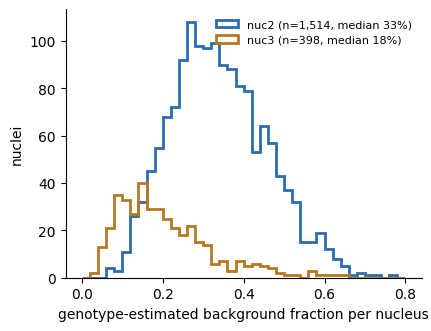

In [9]:
fig, ax = plt.subplots(figsize=(4.2, 3.2), constrained_layout=True)
for rep, color in zip(replicates, ["#2b6cb0", "#b7791f"]):
    gt = metadata[rep]["bRNA"].dropna()
    ax.hist(gt, bins=40, range=(0, 0.8), histtype="step", linewidth=2, color=color,
            label=f"{rep} (n={len(gt):,}, median {gt.median():.0%})")
ax.set_xlabel("genotype-estimated background fraction per nucleus")
ax.set_ylabel("nuclei")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "ground_truth_background.png"), dpi=300, bbox_inches="tight")
plt.show()

## Build the input matrices

CellSweep is run on the raw CellRanger matrix. We take the authors' called cells (so that the
evaluation is on exactly the barcodes their ground truth covers) together with their SingleR cell
type labels, and treat every remaining barcode below `empty_umi_cutoff` as non-cellular. Barcodes
that are neither -- above the cutoff but not called as cells -- are dropped, since they are
neither a labelled cell nor a trustworthy sample of the ambient pool.

In [10]:
def build_adata(rep, empty_umi_cutoff):
    """Raw CellRanger matrix restricted to called cells plus non-cellular barcodes."""
    md_df = metadata[rep]
    adata = cs_utils.load_adata(os.path.join(data_dir, rep, "raw_feature_bc_matrix.h5"), verbose=verbose)
    adata.var_names_make_unique()
    total = np.asarray(adata.X.sum(axis=1)).ravel()

    if empty_umi_cutoff == "knee":  # CellSweep's usual convention: the knee at the expected cell count
        empty_umi_cutoff = int(np.sort(total)[::-1][len(md_df) - 1])

    is_cell = np.asarray(adata.obs_names.isin(md_df.index))
    keep = is_cell | ((total > 0) & (total < empty_umi_cutoff))
    adata = adata[keep].copy()

    adata.obs["total_counts"] = total[keep]
    adata.obs["is_empty"] = ~np.asarray(adata.obs_names.isin(md_df.index))
    adata.obs["celltype"] = pd.Series(md_df["celltype"]).reindex(adata.obs_names).fillna("empty").values
    for src, dst in [("Strain", "Strain"), ("bRNA", "bRNA"), ("nSNP", "nSNP"),
                     ("CI_low", "bRNA_CI_low"), ("CI_high", "bRNA_CI_high")]:
        adata.obs[dst] = pd.Series(md_df[src]).reindex(adata.obs_names).values
    adata.uns["empty_umi_cutoff"] = int(empty_umi_cutoff)

    n_cells, n_empty = int(is_cell.sum()), int((keep & ~is_cell).sum())
    print(f"{rep}: cutoff {empty_umi_cutoff:,} UMI  |  {n_cells:,} cells, {n_empty:,} non-cellular "
          f"barcodes, {int((~is_cell & (total >= empty_umi_cutoff)).sum()):,} barcodes dropped")
    return adata

In [11]:
adata_raw = {}
for rep in replicates:
    path = os.path.join(data_dir, rep, f"adata_raw_empty{empty_umi_cutoff}.h5ad")
    if os.path.exists(path) and not overwrite:
        adata_raw[rep] = ad.read_h5ad(path)
    else:
        adata_raw[rep] = build_adata(rep, empty_umi_cutoff)
        adata_raw[rep].write_h5ad(path)
adata_raw["nuc2"]

AnnData object with n_obs × n_vars = 1478720 × 28692
    obs: 'total_counts', 'is_empty', 'celltype', 'Strain', 'bRNA', 'nSNP', 'bRNA_CI_low', 'bRNA_CI_high'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'empty_umi_cutoff'

### Knee plots

Both replicates show the shallow, poorly separated knee that is characteristic of high-background
droplet data: there is no clean gap between cell-containing and empty barcodes.

In [12]:
def full_knee(rep):
    """Per-barcode totals over the whole raw matrix, read straight from the CellRanger h5.

    The AnnData we hand to CellSweep drops barcodes that are neither called cells nor below the
    noncellular cutoff, so its knee has an artificial cliff; the knee plot has to come from the
    unfiltered matrix."""
    import h5py
    cache = os.path.join(out_dir, f"{rep}_knee.npz")
    if os.path.exists(cache) and not overwrite:
        return np.load(cache)
    with h5py.File(os.path.join(data_dir, rep, "raw_feature_bc_matrix.h5")) as f:
        data, indptr = f["matrix/data"][:], f["matrix/indptr"][:]   # CSC: one column per barcode
    lengths = np.diff(indptr)
    totals = np.zeros(len(lengths), dtype=np.int64)
    nonempty = lengths > 0
    totals[nonempty] = np.add.reduceat(data.astype(np.int64), indptr[:-1][nonempty])
    counts = np.sort(totals[totals > 0])[::-1]
    np.savez_compressed(cache, counts=counts, n_cells=len(metadata[rep]))
    return np.load(cache)

nuc2: knee cutoff at the called-cell count is 1,285 UMI; 62,723 uncalled barcodes sit above the 100-UMI noncellular cutoff
nuc3: knee cutoff at the called-cell count is 2,722 UMI; 76,651 uncalled barcodes sit above the 100-UMI noncellular cutoff


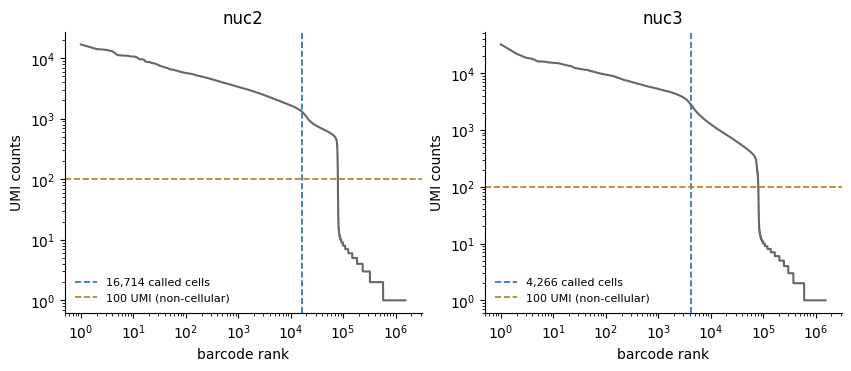

In [13]:
fig, axes = plt.subplots(1, len(replicates), figsize=(4.2 * len(replicates), 3.6), constrained_layout=True)
for ax, rep in zip(np.atleast_1d(axes), replicates):
    knee = full_knee(rep)
    total, n_cells = knee["counts"], int(knee["n_cells"])
    print(f"{rep}: knee cutoff at the called-cell count is {total[n_cells - 1]:,} UMI; "
          f"{np.sum(total >= empty_umi_cutoff) - n_cells:,} uncalled barcodes sit above the "
          f"{empty_umi_cutoff}-UMI noncellular cutoff")
    ax.plot(np.arange(1, len(total) + 1), total, color="0.4", linewidth=1.5)
    ax.axvline(n_cells, color="#2b6cb0", ls="--", linewidth=1.2, label=f"{n_cells:,} called cells")
    ax.axhline(empty_umi_cutoff, color="#b7791f", ls="--", linewidth=1.2,
               label=f"{empty_umi_cutoff} UMI (non-cellular)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("barcode rank"); ax.set_ylabel("UMI counts"); ax.set_title(rep)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "knee_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

## Run CellSweep

In [14]:
%%time
adata_cs = {}
for rep in replicates:
    path = os.path.join(data_dir, rep, f"{rep}_output_cellsweep_empty{empty_umi_cutoff}.h5ad")
    if not os.path.exists(path) or overwrite:
        denoise_count_matrix(
            adata_raw[rep].copy(),
            adata_out=path,
            freeze_ambient_profile=True,
            empty_droplet_method="threshold",
            umi_cutoff=int(adata_raw[rep].uns["empty_umi_cutoff"]),
            threads=threads,
            verbose=verbose,
            log_file=os.path.join(out_dir, f"{rep}_cellsweep_empty{empty_umi_cutoff}.log"),
        )
    adata_cs[rep] = ad.read_h5ad(path)
    adata_cs[rep] = adata_cs[rep][~adata_cs[rep].obs["is_empty"].values].copy()
    print(f"{rep}: beta_hat = {float(adata_cs[rep].uns['beta_hat']):.4f}")

nuc2: beta_hat = 0.0114


nuc3: beta_hat = 0.0003
CPU times: user 2.29 s, sys: 682 ms, total: 2.97 s
Wall time: 2.98 s


### Sanity checks

CellSweep should only ever subtract counts, should not collapse a large share of nuclei to zero,
and should leave per-gene totals monotonically related to the input.

In [15]:
# the raw counts for the same nuclei, as their own AnnData, for the comparison plots below
adata_in = {rep: ad.AnnData(adata_cs[rep].layers["raw"].copy(),
                            obs=adata_cs[rep].obs.copy(), var=adata_cs[rep].var.copy())
            for rep in replicates}

for rep in replicates:
    raw, den = adata_in[rep].X.tocsr(), adata_cs[rep].X.tocsr()
    alpha = adata_cs[rep].obs["alpha_hat"].values
    kept = np.asarray(den.sum(1)).ravel() / np.asarray(raw.sum(1)).ravel()
    print(f"{rep}:")
    print(f"  counts never increase                : {cs_utils.check_counts_less_equal(adata_in[rep], adata_cs[rep])}")
    print(f"  alpha_hat  median {np.median(alpha):.3f}   > 0.5: {(alpha > 0.5).mean():.1%}   > 0.9: {(alpha > 0.9).mean():.1%}")
    print(f"  signal retained per nucleus  median {np.median(kept):.1%}   min {kept.min():.1%}")
    print(f"  nuclei emptied entirely (0 counts left): {(np.asarray(den.sum(1)).ravel() == 0).sum():,}")

nuc2:


  counts never increase                : True
  alpha_hat  median 0.276   > 0.5: 6.9%   > 0.9: 0.0%
  signal retained per nucleus  median 71.6%   min 0.0%
  nuclei emptied entirely (0 counts left): 0
nuc3:


  counts never increase                : True
  alpha_hat  median 0.126   > 0.5: 5.7%   > 0.9: 2.1%
  signal retained per nucleus  median 87.3%   min 0.0%
  nuclei emptied entirely (0 counts left): 0


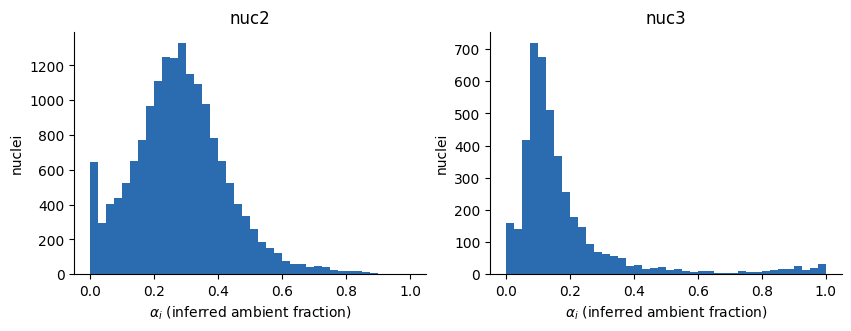

In [16]:
fig, axes = plt.subplots(1, len(replicates), figsize=(4.2 * len(replicates), 3.2), constrained_layout=True)
for ax, rep in zip(np.atleast_1d(axes), replicates):
    ax.hist(adata_cs[rep].obs["alpha_hat"], bins=40, color="#2b6cb0")
    ax.set_xlabel(r"$\alpha_i$ (inferred ambient fraction)"); ax.set_ylabel("nuclei"); ax.set_title(rep)
    ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "alpha_hat_histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

Extracting all nonzero pairs from sparse matrices...


Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


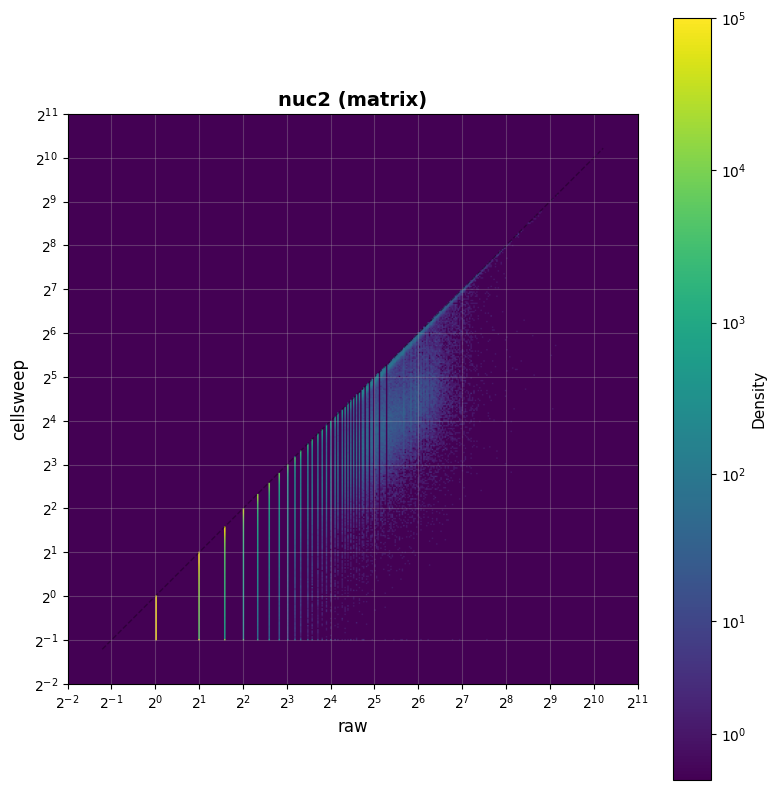

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


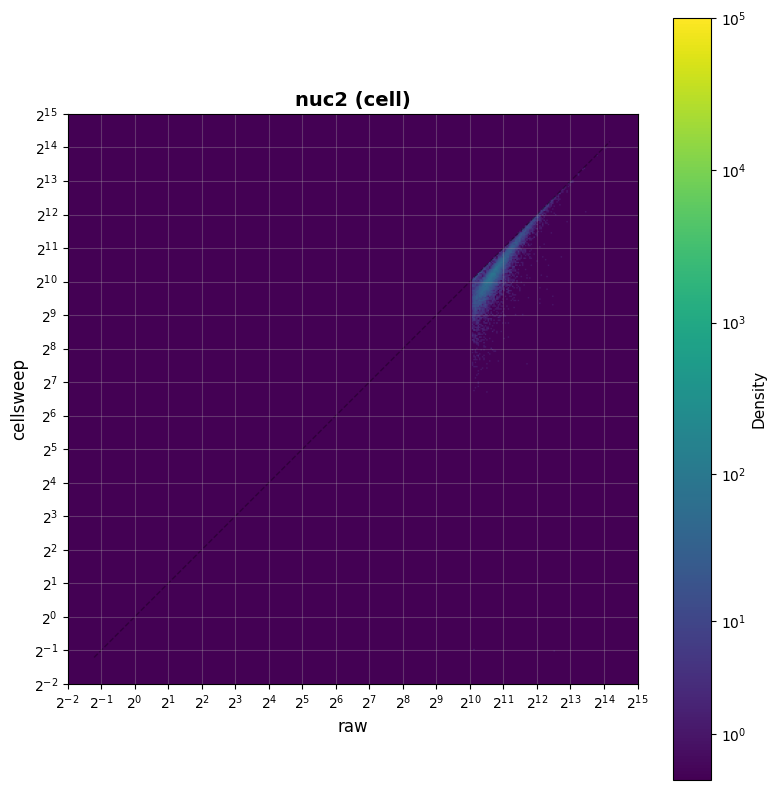

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


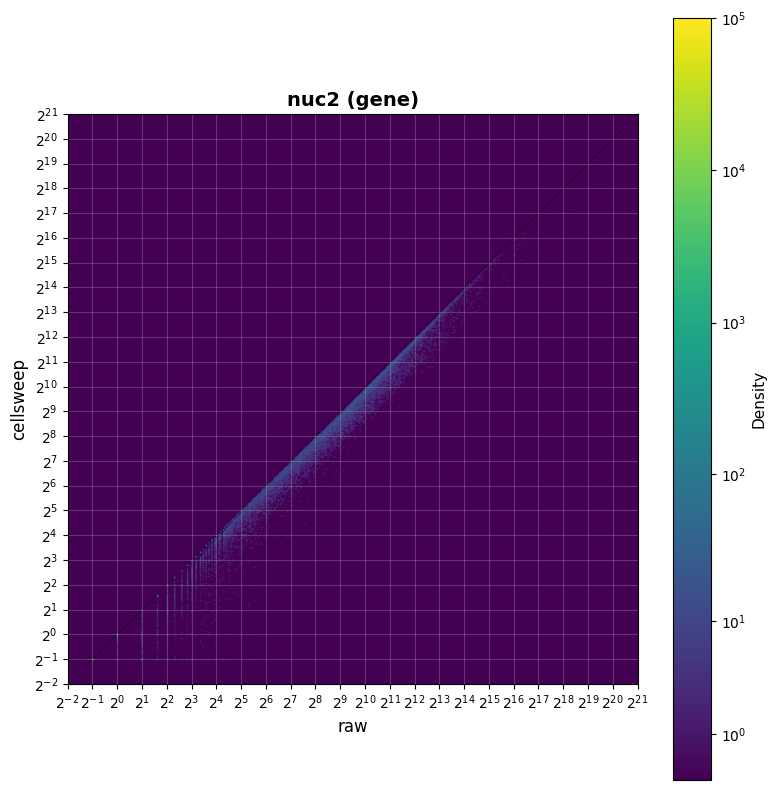

Extracting all nonzero pairs from sparse matrices...


Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


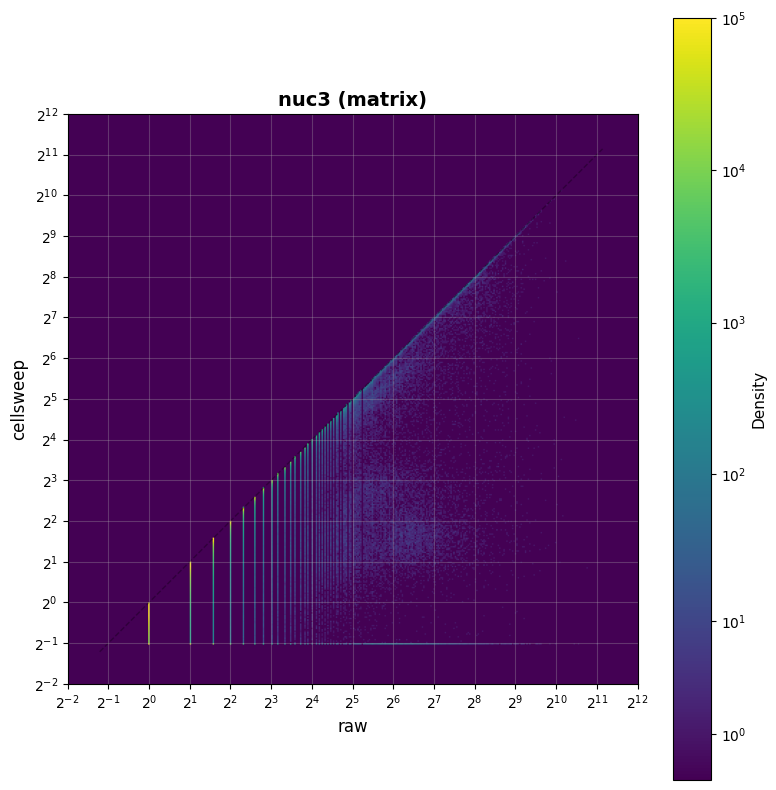

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


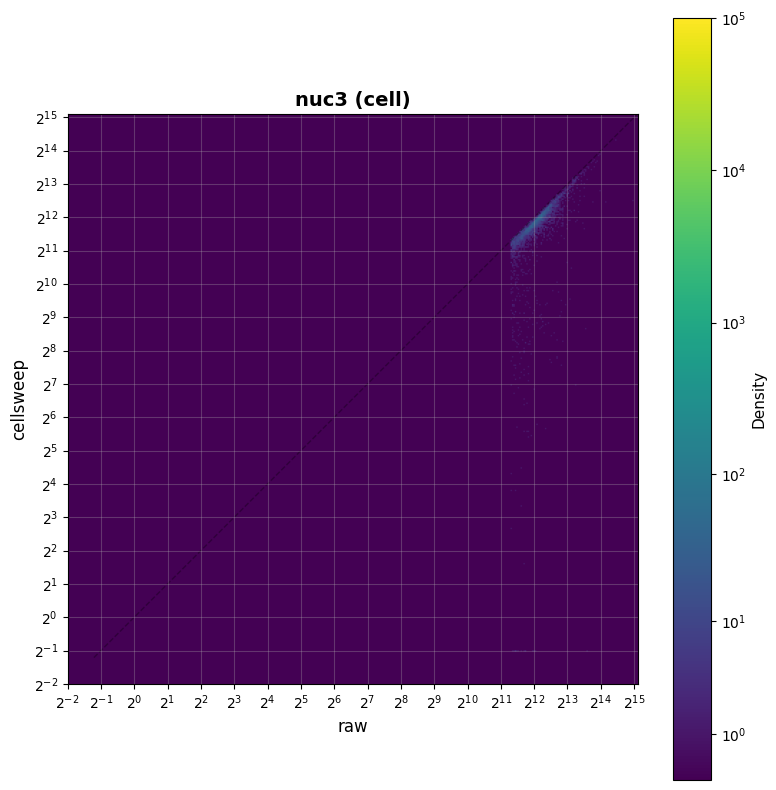

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


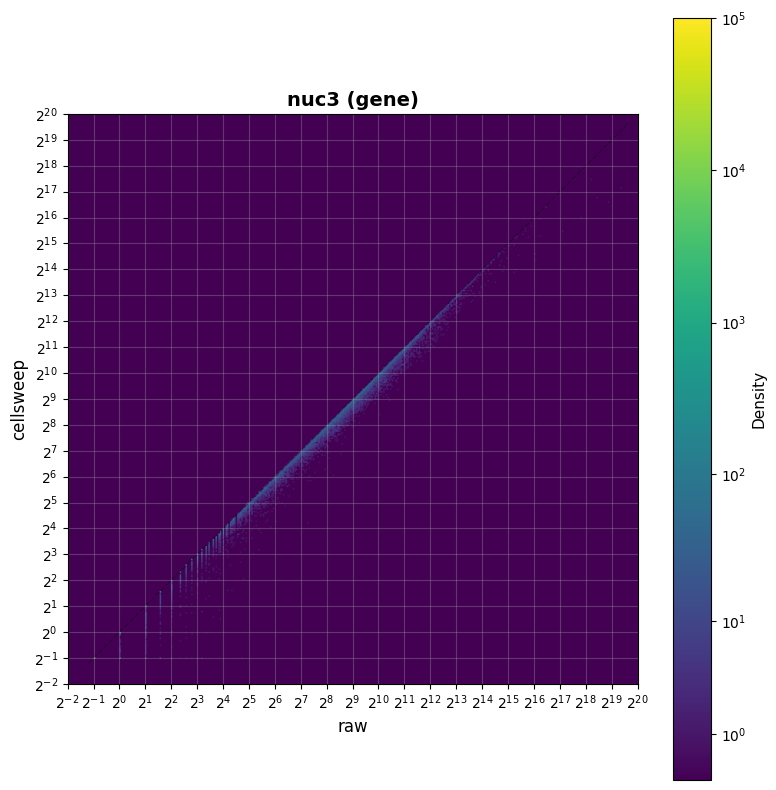

In [17]:
for rep in replicates:
    for point_type in ["matrix", "cell", "gene"]:
        cs_utils.plot_matrix_scatterplot(
            adata_in[rep], adata_cs[rep], point_type=point_type,
            density_type="scatter_with_density", scale="log",
            x_axis="raw", y_axis="cellsweep", title=f"{rep} ({point_type})",
            out_path=os.path.join(out_dir, f"{rep}_scatter_{point_type}.png"))

## Estimation accuracy against the genotype ground truth

Janssen et al. score a method by the fraction of counts it removes from each nucleus,
$\mathrm{cont}_i = 1 - \sum_g \widehat{C}_{ig} / \sum_g C_{ig}$, and compare that to the
genotype estimate with Kendall's $\tau$ and
$\mathrm{RMSLE} = \sqrt{\mathrm{mean}\left[(\log(1+\mathrm{gt}) - \log(1+\mathrm{est}))^2\right]}$
(`Snakemake_benchmark/scripts/evaluate_estimation_accuracy.R`). Their Seurat objects exclude the
13 mitochondrial genes, and the ground truth is likewise computed off mitochondrial reads, so we
drop those genes before summing.

In [18]:
def per_cell_contamination(adata):
    """1 - (denoised counts / raw counts) per nucleus, over non-mitochondrial genes."""
    keep_gene = ~adata.var_names.str.startswith("mt-")
    raw = np.asarray(adata.layers["raw"].tocsr()[:, keep_gene].sum(axis=1)).ravel()
    den = np.asarray(adata.X.tocsr()[:, keep_gene].sum(axis=1)).ravel()
    return 1 - den / np.maximum(raw, 1)


def estimation_accuracy(ground_truth, estimate):
    ok = ~np.isnan(ground_truth)
    gt, est = ground_truth[ok], estimate[ok]
    return dict(n=int(ok.sum()),
                tau=float(kendalltau(gt, est).statistic),
                rmsle=float(np.sqrt(np.mean((np.log1p(gt) - np.log1p(est)) ** 2))))

In [19]:
percell = {}
accuracy = {}
for rep in replicates:
    est = per_cell_contamination(adata_cs[rep])
    percell[rep] = pd.DataFrame({
        "bRNA": adata_cs[rep].obs["bRNA"].values,
        "nSNP": adata_cs[rep].obs["nSNP"].values,
        "est": est,
        "alpha_hat": adata_cs[rep].obs["alpha_hat"].values,
        "celltype": adata_cs[rep].obs["celltype"].values,
        "Strain": adata_cs[rep].obs["Strain"].values,
        "total_counts": np.asarray(adata_cs[rep].layers["raw"].sum(axis=1)).ravel(),
    }, index=adata_cs[rep].obs_names)
    percell[rep].to_csv(os.path.join(out_dir, f"{rep}_percell.csv"))
    accuracy[rep] = estimation_accuracy(percell[rep]["bRNA"].values, percell[rep]["est"].values)
    g = percell[rep].dropna(subset=["bRNA"])
    print(f"{rep}: n={accuracy[rep]['n']}  tau={accuracy[rep]['tau']:.3f}  rmsle={accuracy[rep]['rmsle']:.4f}")
    print(f"      median ground truth {g['bRNA'].median():.1%} vs median CellSweep estimate {g['est'].median():.1%}")

(pd.DataFrame(accuracy).T.rename_axis("replicate").reset_index()
   .to_csv(os.path.join(out_dir, "cellsweep_estimation_accuracy.csv"), index=False))

nuc2: n=1514  tau=0.322  rmsle=0.1132
      median ground truth 33.1% vs median CellSweep estimate 25.9%
nuc3: n=398  tau=0.105  rmsle=0.1929
      median ground truth 18.0% vs median CellSweep estimate 7.7%


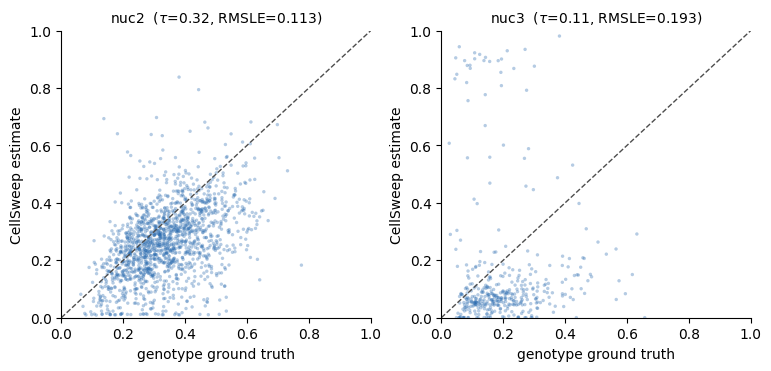

In [20]:
fig, axes = plt.subplots(1, len(replicates), figsize=(3.8 * len(replicates), 3.6), constrained_layout=True)
for ax, rep in zip(np.atleast_1d(axes), replicates):
    g = percell[rep].dropna(subset=["bRNA"])
    ax.scatter(g["bRNA"], g["est"], s=6, alpha=0.35, color="#2b6cb0", edgecolors="none")
    ax.plot([0, 1], [0, 1], color="0.3", ls="--", linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("genotype ground truth"); ax.set_ylabel("CellSweep estimate")
    ax.set_title(f"{rep}  ($\\tau$={accuracy[rep]['tau']:.2f}, RMSLE={accuracy[rep]['rmsle']:.3f})", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "estimate_vs_ground_truth.png"), dpi=300, bbox_inches="tight")
plt.show()

### Against the published benchmark

`Analysis/files/benchmark_metrics.RDS` holds the values Janssen et al. report for CellBender,
DecontX and SoupX, computed by the code above on these same nuclei. The numbers below are
therefore directly comparable; the only method we ran ourselves is CellSweep.

In [21]:
bench = pd.read_csv(os.path.join(data_dir, "benchmark_metrics.csv"))
published = (bench.query("evaluation_category == 'estimation_accuracy' and default")
                  .query("replicate in @replicates")
                  .assign(method=lambda d: np.where(d["param"].str.contains("emptyTrue"),
                                                    d["method"] + " (empty)", d["method"])))
table = published.pivot_table(index=["replicate", "method"], columns="metric", values="value")
for rep in replicates:
    table.loc[(rep, "CellSweep"), "tau"] = accuracy[rep]["tau"]
    table.loc[(rep, "CellSweep"), "rmsle"] = accuracy[rep]["rmsle"]
table = table.sort_index().round(3)
table

metric                     rmsle    tau
replicate method                       
nuc2      CellBender       0.113  0.322
          CellSweep        0.113  0.322
          DecontX          0.162  0.174
          DecontX (empty)  0.091  0.347
          SoupX            0.116  0.169
nuc3      CellBender       0.168  0.101
          CellSweep        0.193  0.105
          DecontX          0.156  0.131
          DecontX (empty)  0.128  0.214
          SoupX            0.106  0.034

## Marker specificity

The kidney is ~90% proximal tubule (PT) in these samples, so PT transcripts dominate the ambient
pool and leak into every other cell type. Janssen et al. quantify this with the *expression
fraction*: over their 10 top PT markers, the mean fraction of non-PT nuclei with a non-zero
(rounded) count, plus the accompanying log ratio between PT and non-PT nuclei
(`Snakemake_benchmark/scripts/evaluate_markers.R` and `combine_results.R`). Lower expression
fraction and higher log ratio are better.

In [22]:
def marker_metrics(X, var_names, celltype, markers=PT_MARKERS):
    idx = [list(var_names).index(g) for g in markers if g in set(var_names)]
    sub = np.round(np.asarray(X[:, idx].todense()) if sp.issparse(X) else np.asarray(X[:, idx]))
    is_pt = celltype == "PT"
    within = (sub[is_pt] > 0).mean(axis=0)
    others = (sub[~is_pt] > 0).mean(axis=0)
    keep = within > 0
    return dict(expression_fraction=float(others[keep].mean()),
                log_ratio_expression=float(np.mean(-np.log((others[keep] + 1) / (within[keep] + 1)))))


def seurat_lfc(X, var_names, celltype, strain, markers=PT_MARKERS):
    """Seurat FindMarkers avg_log2FC for PT vs. the other cell types, on CAST nuclei only."""
    m = strain == "CAST"
    X, ct = X[m], celltype[m]
    total = np.asarray(X.sum(axis=1)).ravel()
    total[total == 0] = 1
    idx = [list(var_names).index(g) for g in markers if g in set(var_names)]
    sub = np.asarray(X[:, idx].todense()) if sp.issparse(X) else np.asarray(X[:, idx])
    norm = np.log1p(sub / total[:, None] * 1e4)     # NormalizeData(LogNormalize, scale.factor = 1e4)
    pt = np.log2(np.expm1(norm[ct == "PT"]).mean(axis=0) + 1)
    other = np.log2(np.expm1(norm[ct != "PT"]).mean(axis=0) + 1)
    return float(np.mean(pt - other))

In [23]:
marker_rows = []
for rep in replicates:
    a = adata_cs[rep]
    keep_gene = ~a.var_names.str.startswith("mt-")
    names = a.var_names[keep_gene]
    ct = a.obs["celltype"].values.astype(str)
    st = a.obs["Strain"].values.astype(str)
    for label, X in [("raw", a.layers["raw"].tocsr()[:, keep_gene]), ("CellSweep", a.X.tocsr()[:, keep_gene])]:
        row = dict(replicate=rep, method=label, **marker_metrics(X, names, ct))
        row["lfc"] = seurat_lfc(X, names, ct, st)
        marker_rows.append(row)
marker_df = pd.DataFrame(marker_rows)
marker_df.to_csv(os.path.join(out_dir, "marker_metrics.csv"), index=False)
marker_df.round(3)

,replicate,method,expression_fraction,log_ratio_expression,lfc
0,nuc2,raw,0.478,0.111,1.066
1,nuc2,CellSweep,0.249,0.230,1.617
2,nuc3,raw,0.417,0.249,2.151
3,nuc3,CellSweep,0.257,0.358,2.588


The expression fraction is a hard threshold -- a nucleus counts as "expressing" if a single
rounded count survives -- so it is unforgiving of an estimator that subtracts the *expected*
ambient contribution and leaves the Poisson residual behind. The underlying magnitude is a more
direct read on how much off-target signal is gone:

In [24]:
for rep in replicates:
    a = adata_cs[rep]
    idx = [a.var_names.get_loc(g) for g in PT_MARKERS]
    other = a.obs["celltype"].values.astype(str) != "PT"
    raw = np.asarray(a.layers["raw"].tocsr()[:, idx].todense())[other]
    den = np.asarray(a.X.tocsr()[:, idx].todense())[other]
    print(f"{rep}: PT-marker counts in {other.sum():,} non-PT nuclei: "
          f"{raw.sum():,.0f} -> {den.sum():,.0f} ({1 - den.sum()/raw.sum():.1%} removed); "
          f"mean per nucleus {raw.sum(1).mean():.2f} -> {den.sum(1).mean():.2f}")

nuc2: PT-marker counts in 2,419 non-PT nuclei: 23,615 -> 9,246 (60.8% removed); mean per nucleus 9.76 -> 3.82
nuc3: PT-marker counts in 431 non-PT nuclei: 3,998 -> 1,848 (53.8% removed); mean per nucleus 9.28 -> 4.29


In [25]:
published_markers = (bench.query("evaluation_category == 'marker_evaluation' and default")
                          .query("replicate in @replicates")
                          .assign(method=lambda d: np.where(d["param"].str.contains("emptyTrue"),
                                                            d["method"] + " (empty)", d["method"]))
                          .pivot_table(index=["replicate", "method"], columns="metric", values="value"))
combined_markers = pd.concat([
    published_markers,
    marker_df.set_index(["replicate", "method"])[["expression_fraction", "log_ratio_expression", "lfc"]],
]).sort_index().round(3)
combined_markers

expression_fraction    lfc  log_ratio_expression
replicate method                                                           
nuc2      CellBender                     0.022  3.726                 0.323
          CellSweep                      0.249  1.617                 0.230
          DecontX                        0.430  1.328                 0.129
          DecontX (empty)                0.086  2.163                 0.296
          SoupX                          0.042  2.845                 0.191
          raw                            0.478  1.066                 0.111
          raw                            0.478  1.066                 0.111
nuc3      CellSweep                      0.257  2.588                 0.358
          raw                            0.417  2.151                 0.249

## Sensitivity to the non-cellular barcode cutoff

CellSweep estimates the ambient profile $\mathbf{a}$ from non-cellular barcodes, so the cutoff
that defines them matters more here than in low-background data. At the knee (1,285 UMI for
`nuc2`, 2,722 for `nuc3`) a large number of near-cell barcodes are pulled into the ambient
profile, which makes $\mathbf{a}$ resemble a real nucleus and drives some nuclei to
$\alpha_i \to 1$. We rerun both replicates across a range of cutoffs.

In [26]:
%%time
sweep_rows = []
for rep in replicates:
    for cutoff in empty_cutoff_sweep:
        tag = f"empty{cutoff}"
        raw_path = os.path.join(data_dir, rep, f"adata_raw_{tag}.h5ad")
        out_path = os.path.join(data_dir, rep, f"{rep}_output_cellsweep_{tag}.h5ad")
        if not os.path.exists(out_path) or overwrite:
            a = ad.read_h5ad(raw_path) if os.path.exists(raw_path) else build_adata(rep, cutoff)
            if not os.path.exists(raw_path):
                a.write_h5ad(raw_path)
            denoise_count_matrix(a, adata_out=out_path, freeze_ambient_profile=True,
                                 empty_droplet_method="threshold",
                                 umi_cutoff=int(a.uns["empty_umi_cutoff"]), threads=threads,
                                 verbose=0, log_file=os.path.join(out_dir, f"{rep}_cellsweep_{tag}.log"))
        a = ad.read_h5ad(out_path)
        a = a[~a.obs["is_empty"].values].copy()
        est = per_cell_contamination(a)
        row = dict(replicate=rep, cutoff=cutoff, umi=int(a.uns["empty_umi_cutoff"]),
                   frac_alpha_above_0p9=float((a.obs["alpha_hat"].values > 0.9).mean()),
                   median_estimate=float(np.median(est)),
                   **estimation_accuracy(a.obs["bRNA"].values.astype(float), est))
        sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(os.path.join(out_dir, "empty_cutoff_sweep.csv"), index=False)
sweep_df.round(3)

CPU times: user 11.1 s, sys: 2.59 s, total: 13.6 s
Wall time: 13.7 s


,replicate,cutoff,umi,frac_alpha_above_0p9,median_estimate,n,tau,rmsle
0,nuc2,100,100,0.000,0.242,1514,0.322,0.113
1,nuc2,500,500,0.012,0.328,1514,0.258,0.100
2,nuc2,1000,1000,0.019,0.334,1514,0.263,0.101
3,nuc2,knee,1285,0.017,0.332,1514,0.270,0.100
4,nuc3,100,100,0.021,0.071,398,0.105,0.193
5,nuc3,500,500,0.037,0.104,398,0.057,0.215
6,nuc3,1000,1000,0.054,0.116,398,-0.003,0.279
7,nuc3,knee,2722,0.105,0.101,398,0.012,0.318


Raising the cutoff pulls near-cell barcodes into the ambient profile, which pushes more nuclei to
$\alpha_i \to 1$. In `nuc3`, where the called cells are few and the background heavy, the cutoff at
the called-cell count sends 10.5% of nuclei above $\alpha_i = 0.9$ and leaves $\tau$ near zero.

## Manuscript figures

`scripts/make_janssen_figure.py` assembles the panels above, together with the published
CellBender / DecontX / SoupX values, into the two supplementary figures.

metric                     rmsle    tau
replicate method                       
nuc2      CellBender       0.113  0.322
          CellSweep        0.113  0.322
          DecontX          0.162  0.174
          DecontX (empty)  0.091  0.347
          SoupX            0.116  0.169
nuc3      CellBender       0.168  0.101
          CellSweep        0.193  0.105
          DecontX          0.156  0.131
          DecontX (empty)  0.128  0.214
          SoupX            0.106  0.034
metric                     expression_fraction    lfc  log_ratio_expression
replicate method                                                           
nuc2      CellBender                     0.022  3.726                 0.323
          CellSweep                      0.249  1.617                 0.230
          DecontX                        0.430  1.328                 0.129
          DecontX (empty)                0.086  2.163                 0.296
          SoupX                          0.042  2.845           

wrote /home/jrich/Desktop/cellsweep/notebooks/output/janssen2023/janssen_snrna_figure.png


wrote /home/jrich/Desktop/cellsweep/notebooks/output/janssen2023/janssen_cutoff_sensitivity.png


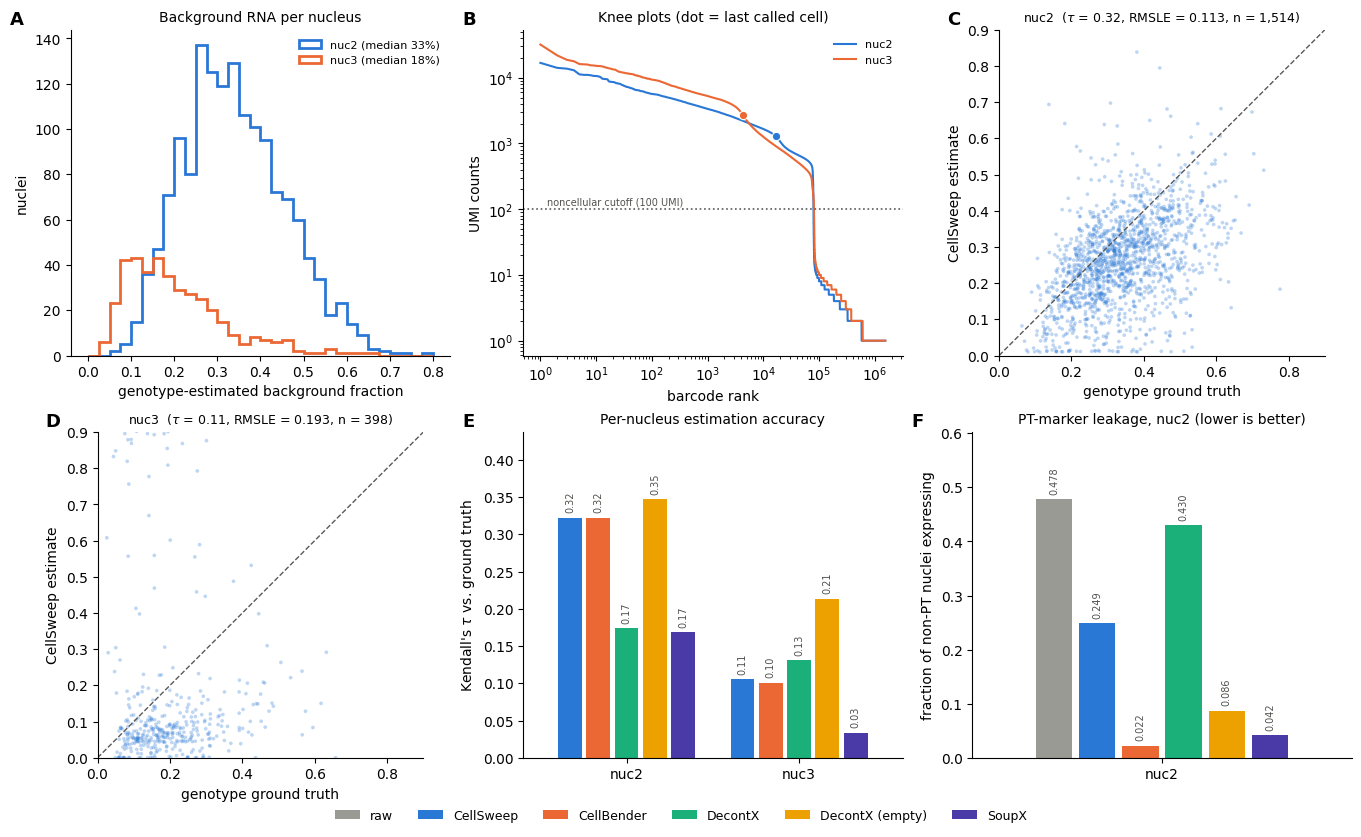

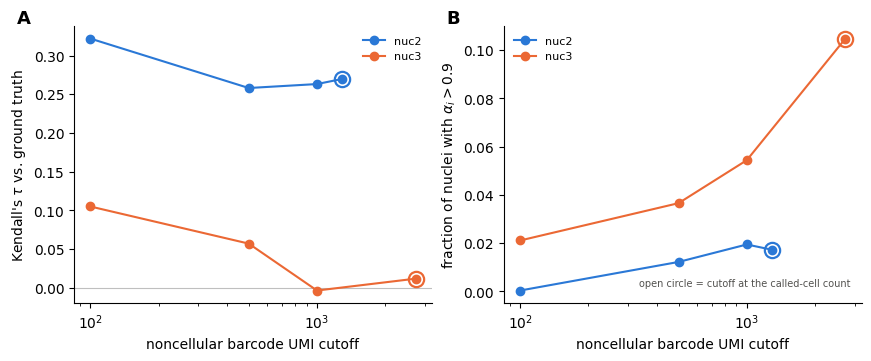

In [27]:
import sys
sys.path.insert(0, os.path.join(cellsweep_dir, "scripts"))
import make_janssen_figure as mjf

inputs = mjf.load_inputs(data_dir, out_dir)
print(inputs[3].round(3).to_string())   # estimation accuracy, all methods
print(inputs[4].round(3).to_string())   # marker metrics, all methods
_ = mjf.build_figure(*inputs, os.path.join(out_dir, "janssen_snrna_figure.png"))
_ = mjf.build_sensitivity_figure(sweep_df, os.path.join(out_dir, "janssen_cutoff_sensitivity.png"))